# Customer Churn Data Analysis 

In [60]:
# 1. Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
# 2. Load dataset
df = pd.read_csv(r"C:\Users\Hp\Downloads\WA_Fn-UseC_-Telco-Customer-Churn (2).csv")

In [62]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [63]:
df.shape

(7043, 21)

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [65]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [66]:
# 3. Data cleaning
# Convert TotalCharges to numeric and handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [67]:
# Drop customerID (not useful for prediction)
df.drop('customerID', axis=1, inplace=True)

In [68]:
# 4. Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

C:\Users\Hp\AppData\Local\Temp\ipykernel_16596\4207057719.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


In [69]:
# 5. Features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

In [70]:
# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [71]:
# 7. Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [72]:
# 8. Model training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [73]:
# 9. Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [76]:
# 10. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

*Accuracy*: 0.7991483321504613

Confusion Matrix:
 [[921 114]
 [169 205]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


ROC-AUC Score: 0.8402490376914928


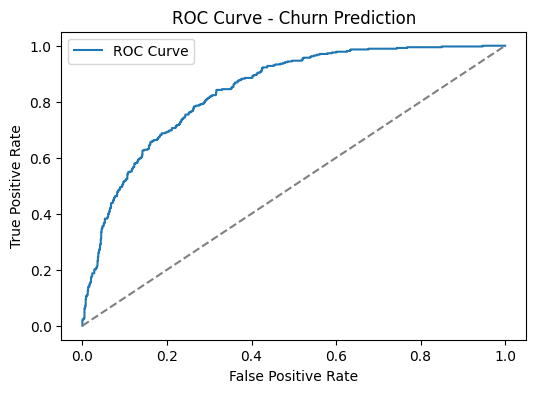

In [75]:
# 11. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Churn Prediction")
plt.legend()
plt.show()


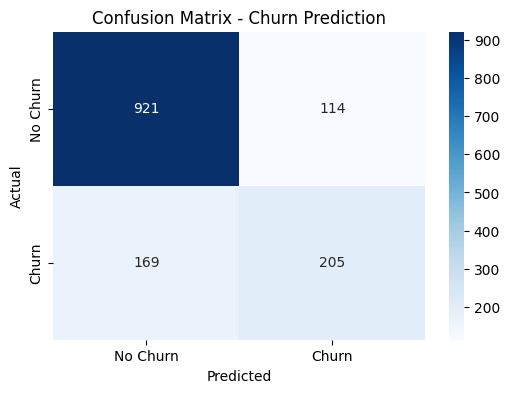

In [77]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Churn Prediction')
plt.show()


In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [37]:
# Load data
df = pd.read_csv(r"C:\Users\Hp\Downloads\WA_Fn-UseC_-Telco-Customer-Churn (2).csv")

In [38]:
# View data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning

In [39]:
# Check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [40]:
# Fix TotalCharges (convert to numeric)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [41]:
# Fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_16596\457876299.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [42]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [43]:
# Convert data types
df['SeniorCitizen'] = df['SeniorCitizen'].astype('category')

In [44]:
# Outlier Handling (IQR method)
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['MonthlyCharges'] >= Q1 - 1.5*IQR) & 
        (df['MonthlyCharges'] <= Q3 + 1.5*IQR)]

print("Cleaned Data Shape:", df.shape)

Cleaned Data Shape: (7043, 21)


## EDA

#### 1. Univariate Analysis

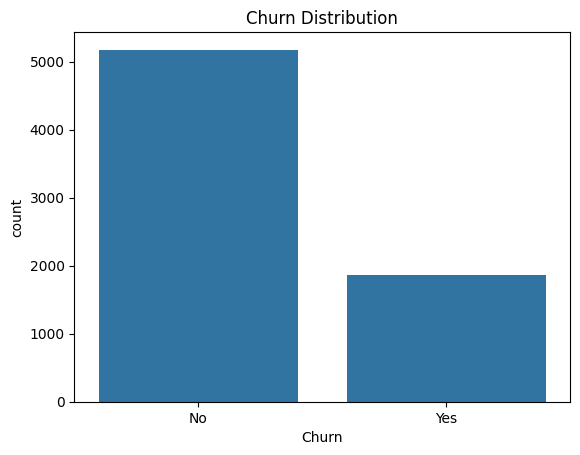

In [45]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

#### 2. Bivariate Analysis

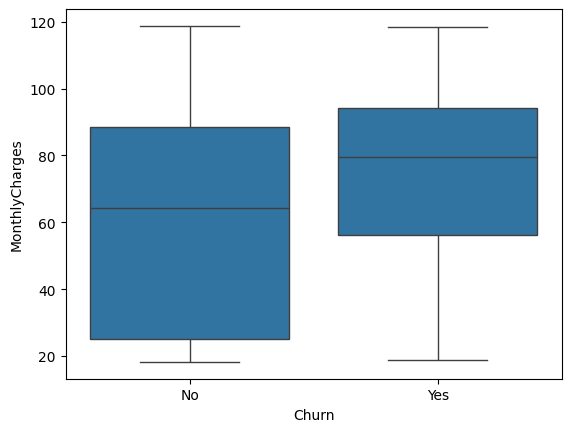

In [46]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

#### 3. Multivariate

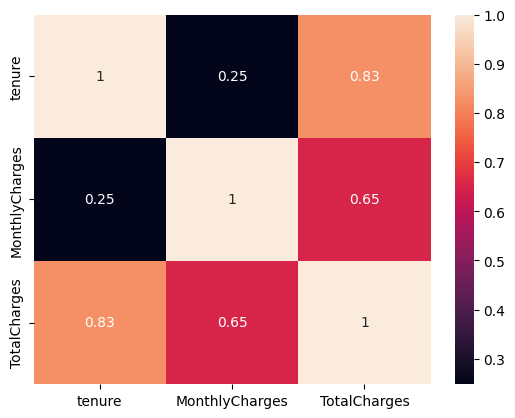

In [47]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [48]:
import os

print(os.getcwd())        # current folder
print(os.listdir())       # files in that folder

C:\Users\Hp
['# Bagging Regressoin Algorithms.ipynb', '.anaconda', '.cache', '.codex', '.conda', '.condarc', '.continuum', '.copilot', '.cursor', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.matplotlib', '.streamlit', '.virtual_documents', '.vscode', '1.ipynb', '10.ipynb', '14.ipynb', '3 .ipynb', '3.ipynb', '3D Objects', '4 .ipynb', '5 .ipynb', '6 .ipynb', '6.ipynb', '7 .ipynb', '7.ipynb', '8 .ipynb', '8.ipynb', '9.ipynb', 'A.ipynb', 'aaa', 'AAAAA.ipynb', 'AddingAndRemoving.ipynb', 'AddingAndRemovingArrayELEMENTS.ipynb', 'AggregatingFunctions.ipynb', 'All Encoding One Place.ipynb', 'anaconda3', 'ANN chrun model.ipynb', 'ANN churn model .ipynb', 'ann regression.ipynb', 'ANN.ipynb', 'AppData', 'Application Data', 'Apriori algorithm in .ipynb', 'Array.ipynb', 'Association Learning in Apriori algorithm  .ipynb', 'AssociationRule Learning Apriori and FpGrowth .ipynb', 'B - feature scaling.ipynb', 'Bagging Regressor Algorithm .ipynb', 'BArPloTPANDAS.ipynb', 'BarPlotSEABORN.ipynb

In [49]:
df.to_csv(r"C:\Users\Hp\Downloads\claned_telco_churn.csv", index=False)

In [50]:
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

In [51]:
df.isnull().sum().sum()

11

In [52]:
df.fillna(0, inplace=True).head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [53]:
df.isnull().sum().sum()

0

In [54]:
le = LabelEncoder()

In [55]:
for col in df.columns:
    
    # Check object/string columns
    if df[col].dtype == 'object':
        
        df[col] = label_encoder.fit_transform(df[col])

In [56]:
# # label encoding

# for column in df.columns:
#     if df[column].dtype == 'object':
#         df[column] = le.fit_transform(df[column])

In [57]:
# Step 8: Split Features and Target
X = df.drop('Churn', axis=1)
y = df['Churn']

In [58]:
# Step 9: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [59]:
# Step 10: Train Model
model = RandomForestClassifier()

model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Female'